# BTC forecasting benchmark notebook

Compare classical ML, stochastic SDE, and hybrid SDE + ML models on the same BTC dataset, with optional RandomizedSearchCV tuning for ML and hybrid drift models.

In [1]:
%pip install -r requirements.txt


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import get_data
from src.evaluation.metrics import (
    metrics_frame,
    regression_metrics,
    paired_t_test_errors,
    paired_tests_table,
    directional_accuracy,
    naive_last_value_forecast,
)
from src.models.elastic_net_model import ElasticNetModel
from src.models.gradient_boosting_model import GradientBoostingModel
from src.models.random_forest_model import RandomForestModel
from src.models.hybrid_model import (
    HybridSDEMLModel,
    HybridSDEElasticNetModel,
    HybridSDERandomForestModel,
)
from src.models.sde_models import GBMModel, MertonJumpDiffusionModel, HestonModel
from src.models.economic_metrics import compare_strategies
from src.models.walk_forward import walk_forward_cv, walk_forward_summary, walk_forward_naive_baseline, walk_forward_price_model

plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
TICKERS = {'BTC-USD': 'BTC'}
INTERVAL = '15m'
START_DATE = '2026-03-15'
END_DATE = '2026-05-15'
HORIZON = 10
DT = 1/96
TEST_SIZE = 0.2
PRICE_LAGS = 10
VOLUME_LAGS = 5
CONTEXT_BARS = 80
N_SDE_PATHS = 500
USE_TUNING = True
TUNING_ITERATIONS = 20
TUNING_CV_SPLITS = 3
TUNING_VERBOSE = 2

In [4]:
def make_supervised_frame(df: pd.DataFrame, horizon: int = 10) -> pd.DataFrame:
    out = df.copy()

    # for lag in range(1, PRICE_LAGS + 1):
    #     out[f'close_lag_{lag}'] = out['BTC_Close'].shift(lag)

    out[f'close_lag_10'] = out['BTC_Close'].shift(10)

    # for lag in range(1, VOLUME_LAGS + 1):
    #     out[f'volume_lag_{lag}'] = out['BTC_Volume'].shift(lag)

    out['high_lag_1'] = out['BTC_High'].shift(1)
    out['low_lag_1'] = out['BTC_Low'].shift(1)
    out['hl_range_lag_1'] = (out['BTC_High'] - out['BTC_Low']).shift(1)
    out['sma_20_lag_1'] = out['BTC_Close'].rolling(20).mean().shift(1)

    delta = out['BTC_Close'].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / loss.replace(0, np.nan)
    out['rsi_14_lag_1'] = (100 - (100 / (1 + rs))).shift(1)
    out['rsi_14_lag_1'] = out['rsi_14_lag_1'].fillna(50.0)

    out['target'] = out['BTC_Close'].shift(-horizon)
    return out.dropna().reset_index(drop=True)


def maybe_tune_tabular_model(model, X_train, y_train):
    if USE_TUNING and hasattr(model, 'tuning_space'):
        print(f'\nTuning {model.model_name}...')
        model.tune(
            X_train,
            y_train,
            param_distributions=model.tuning_space(),
            n_iter=TUNING_ITERATIONS,
            cv_splits=TUNING_CV_SPLITS,
            verbose=TUNING_VERBOSE,
        )
        print('Best params:', model.best_params_)
    else:
        model.fit(X_train, y_train)
    return model


def maybe_tune_hybrid_model(model, train_prices, dt: float):
    if USE_TUNING and hasattr(model, 'tuning_space'):
        print(f'\nTuning {model.model_name}...')
        model.tune(
            train_prices,
            param_distributions=model.tuning_space(),
            dt=dt,
            n_iter=TUNING_ITERATIONS,
            cv_splits=TUNING_CV_SPLITS,
            verbose=TUNING_VERBOSE,
        )
        print('Best params:', model.best_params_)
    else:
        model.fit(train_prices, dt=dt)
    return model


def evaluate_tabular_model(model, X_train, y_train, X_test, y_test) -> tuple[dict, np.ndarray]:
    model = maybe_tune_tabular_model(model, X_train, y_train)
    y_pred = model.predict(X_test)
    metrics = {'model': model.model_name, **regression_metrics(y_test, y_pred)}
    if X_test.shape[1] > 0:
        metrics.update(directional_accuracy(y_test, y_pred, X_test[:, 0]))
    return metrics, y_pred


def evaluate_sde_model(model, train_prices, eval_prices, horizon: int, dt: float, n_paths: int) -> tuple[dict, np.ndarray, np.ndarray]:
    print(f'\nFitting {model.model_name}...')
    model.fit(train_prices, dt=dt)
    y_pred = model.rolling_forecast(eval_prices, horizon=horizon, n_paths=n_paths, dt=dt)
    y_true = eval_prices[horizon:horizon + len(y_pred)]
    reference = eval_prices[:len(y_pred)]
    metrics = {'model': model.model_name, **regression_metrics(y_true, y_pred)}
    metrics.update(directional_accuracy(y_true, y_pred, reference))
    return metrics, y_true, y_pred


def evaluate_hybrid_model(model, train_prices, eval_prices, horizon: int, dt: float) -> tuple[dict, np.ndarray, np.ndarray]:
    model = maybe_tune_hybrid_model(model, train_prices, dt=dt)
    y_pred = model.predict_point(eval_prices, horizon=horizon, dt=dt)
    lag = model.n_lag_returns
    y_true = eval_prices[lag + horizon: lag + horizon + len(y_pred)]
    reference = eval_prices[lag:lag + len(y_pred)]
    metrics = {'model': model.model_name, **regression_metrics(y_true, y_pred)}
    metrics.update(directional_accuracy(y_true, y_pred, reference))
    return metrics, y_true, y_pred

In [5]:
df = get_data(
    ticker_names=TICKERS,
    start_date=START_DATE,
    end_date=END_DATE,
    interval=INTERVAL,
    price_type=['High', 'Low', 'Close', 'Volume'],
    progress=False,
).dropna().reset_index(drop=True)

df.head(30)

15m
2026-03-21 00:00:00 2026-05-19 00:00:00
{'BTC-USD': 'BTC'} 2026-03-15 2026-03-21 00:00:00
{'BTC-USD': 'BTC'} 2026-05-15 2026-05-19 00:00:00
[INFO] Data successfully loaded: 2026-03-21 to 2026-05-19.
--------------------------------------------------


,Datetime,BTC_Close,BTC_High,BTC_Low,BTC_Volume
0,2026-03-21 00:00:00+00:00,70532.08,70580.03,70490.82,0
1,2026-03-21 00:15:00+00:00,70680.39,70762.16,70577.38,78888960
2,2026-03-21 00:30:00+00:00,70615.20,70672.25,70592.22,0
3,2026-03-21 00:45:00+00:00,70695.88,70707.34,70583.59,37527552
4,2026-03-21 01:00:00+00:00,70679.72,70742.89,70653.13,0
5,2026-03-21 01:15:00+00:00,70637.50,70670.54,70595.55,16994304
6,2026-03-21 01:30:00+00:00,70563.85,70630.14,70550.93,89473024
7,2026-03-21 01:45:00+00:00,70483.45,70567.50,70483.45,15286272
8,2026-03-21 02:00:00+00:00,70476.45,70497.45,70438.75,117010432
9,2026-03-21 02:15:00+00:00,70664.18,70664.18,70480.34,0


In [6]:
prices = df['BTC_Close'].to_numpy(dtype=float)
supervised_df = make_supervised_frame(df, horizon=HORIZON)
feature_cols = ['BTC_Close', 'BTC_High', 'BTC_Low', 'BTC_Volume', 'close_lag_10', 'high_lag_1', 'low_lag_1', 'hl_range_lag_1', 'sma_20_lag_1', 'rsi_14_lag_1']

split_idx = int(len(prices) * (1 - TEST_SIZE))
train_prices = prices[:split_idx]
eval_prices = prices[max(0, split_idx - CONTEXT_BARS):]

split_supervised = int(len(supervised_df) * (1 - TEST_SIZE))
train_df = supervised_df.iloc[:split_supervised].copy()
test_df = supervised_df.iloc[split_supervised:].copy()
eval_start_index = max(0, split_idx - CONTEXT_BARS)

naive_pred_raw = list(test_df['close_lag_10'])
test_df = test_df.drop('close_lag_10', axis=1)
train_df = train_df.drop('close_lag_10', axis=1)
feature_cols.remove('close_lag_10')

X_train = train_df[feature_cols].to_numpy(dtype=float)
y_train = train_df['target'].to_numpy(dtype=float)
X_test = test_df[feature_cols].to_numpy(dtype=float)
y_test = test_df['target'].to_numpy(dtype=float)

len(train_prices), len(eval_prices), X_train.shape, X_test.shape

(4483, 1201, (4459, 9), (1115, 9))

In [7]:
train_df

,Datetime,BTC_Close,BTC_High,BTC_Low,BTC_Volume,high_lag_1,low_lag_1,hl_range_lag_1,sma_20_lag_1,rsi_14_lag_1,target
0,2026-03-21 05:00:00+00:00,70648.03,70689.23,70632.20,31911936,70653.34,70629.31,24.03,70648.47,49.68,70777.55
1,2026-03-21 05:15:00+00:00,70771.91,70771.91,70646.05,94539776,70689.23,70632.20,57.03,70654.27,55.60,70697.63
2,2026-03-21 05:30:00+00:00,70728.84,70782.82,70717.16,462524416,70771.91,70646.05,125.85,70658.85,68.15,70710.38
3,2026-03-21 05:45:00+00:00,70704.13,70761.70,70686.18,160071680,70782.82,70717.16,65.66,70664.53,65.19,70536.15
4,2026-03-21 06:00:00+00:00,70721.11,70724.45,70696.58,0,70761.70,70686.18,75.52,70664.94,52.99,70623.11
...,...,...,...,...,...,...,...,...,...,...,...
4454,2026-05-07 02:30:00+00:00,80965.11,81042.87,80900.00,306323456,80992.73,80890.00,102.73,81255.86,34.76,81111.47
4455,2026-05-07 02:45:00+00:00,81118.60,81149.81,80965.11,13422592,81042.87,80900.00,142.87,81225.62,40.33,81098.22
4456,2026-05-07 03:00:00+00:00,81020.98,81109.25,81015.00,54091776,81149.81,80965.11,184.70,81204.59,40.34,81078.69
4457,2026-05-07 03:15:00+00:00,80975.91,81073.21,80864.99,0,81109.25,81015.00,94.25,81186.97,38.55,81085.99


In [8]:
y_train

array([70777.5546875, 70697.6328125, 70710.3828125, ..., 81078.6875   ,
       81085.9921875, 80891.4296875], shape=(4459,))

In [9]:
test_df_temp = test_df.copy()

In [10]:
ml_models = [
    ElasticNetModel(alpha=0.001, l1_ratio=0.5, random_state=42),
    GradientBoostingModel(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42),
    RandomForestModel(n_estimators=300, max_depth=8, random_state=42),
]

sde_models = [
    GBMModel(random_state=42),
    MertonJumpDiffusionModel(random_state=42),
    HestonModel(random_state=42),
]

hybrid_models = [
    HybridSDEMLModel(random_state=42),
    HybridSDEElasticNetModel(random_state=42),
    HybridSDERandomForestModel(random_state=42),
]

In [11]:
results = []
predictions = {}
best_params = {}
reference_series = {}

for model in ml_models:
    metrics, y_pred = evaluate_tabular_model(model, X_train, y_train, X_test, y_test)
    results.append(metrics)
    predictions[model.model_name] = (y_test, y_pred)
    reference_series[model.model_name] = X_test[:, 0]
    test_df_temp[model.model_name+'_pred'] = y_pred
    if getattr(model, 'best_params_', None) is not None:
        best_params[model.model_name] = model.best_params_

# Persistence baseline must be evaluated on the same supervised test rows as tabular ML models.
# Here close_lag_1 is the last observed price available at forecast origin.
naive_true = y_test
naive_pred = naive_pred_raw
naive_ref = naive_pred_raw
naive_metrics_row = {'model': 'Naive persistence', **regression_metrics(naive_true, naive_pred)}
naive_metrics_row.update(directional_accuracy(naive_true, naive_pred, naive_ref))
results.append(naive_metrics_row)
predictions['Naive persistence'] = (naive_true, naive_pred)
reference_series['Naive persistence'] = naive_ref

for model in sde_models:
    metrics, y_true, y_pred = evaluate_sde_model(
        model,
        train_prices=train_prices,
        eval_prices=eval_prices,
        horizon=HORIZON,
        dt=DT,
        n_paths=N_SDE_PATHS,
    )
    results.append(metrics)
    predictions[model.model_name] = (y_true, y_pred)
    reference_series[model.model_name] = eval_prices[:len(y_pred)]

for model in hybrid_models:
    metrics, y_true, y_pred = evaluate_hybrid_model(
        model,
        train_prices=train_prices,
        eval_prices=eval_prices,
        horizon=HORIZON,
        dt=DT,
    )
    results.append(metrics)
    predictions[model.model_name] = (y_true, y_pred)
    reference_series[model.model_name] = eval_prices[model.n_lag_returns:model.n_lag_returns + len(y_pred)]
    if getattr(model, 'best_params_', None) is not None:
        best_params[model.model_name] = model.best_params_


Tuning ElasticNet...
Fitting 3 folds for each of 20 candidates, totalling 60 fits


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.362e+08, tolerance: 3.266e+05
  model = cd_fast.enet_coordinate_descent(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.565e+08, tolerance: 9.923e+05
  model = cd_fast.enet_coordinate_descent(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.362e+08, toleranc

[CV] END ..........alpha=0.0002310129700083158, l1_ratio=0.7; total time=   0.0s
[CV] END ..........alpha=0.0002915053062825176, l1_ratio=0.2; total time=   0.0s
[CV] END ..........alpha=0.017073526474706904, l1_ratio=0.35; total time=   0.0s
[CV] END ..........alpha=0.027185882427329403, l1_ratio=0.95; total time=   0.0s
[CV] END .........alpha=1.788649529057435e-05, l1_ratio=0.85; total time=   0.0s
[CV] END ..........alpha=0.0002915053062825176, l1_ratio=0.2; total time=   0.0s
[CV] END ..........alpha=0.017073526474706904, l1_ratio=0.35; total time=   0.0s
[CV] END ..........alpha=0.0002915053062825176, l1_ratio=0.2; total time=   0.0s
[CV] END ..........alpha=0.0002310129700083158, l1_ratio=0.7; total time=   0.0s
[CV] END .........alpha=1.788649529057435e-05, l1_ratio=0.85; total time=   0.0s
[CV] END ..........alpha=0.017073526474706904, l1_ratio=0.35; total time=   0.0s
[CV] END ..........alpha=0.0002310129700083158, l1_ratio=0.7; total time=   0.0s
[CV] END .........alpha=1.78

In [12]:
train_df

,Datetime,BTC_Close,BTC_High,BTC_Low,BTC_Volume,high_lag_1,low_lag_1,hl_range_lag_1,sma_20_lag_1,rsi_14_lag_1,target
0,2026-03-21 05:00:00+00:00,70648.03,70689.23,70632.20,31911936,70653.34,70629.31,24.03,70648.47,49.68,70777.55
1,2026-03-21 05:15:00+00:00,70771.91,70771.91,70646.05,94539776,70689.23,70632.20,57.03,70654.27,55.60,70697.63
2,2026-03-21 05:30:00+00:00,70728.84,70782.82,70717.16,462524416,70771.91,70646.05,125.85,70658.85,68.15,70710.38
3,2026-03-21 05:45:00+00:00,70704.13,70761.70,70686.18,160071680,70782.82,70717.16,65.66,70664.53,65.19,70536.15
4,2026-03-21 06:00:00+00:00,70721.11,70724.45,70696.58,0,70761.70,70686.18,75.52,70664.94,52.99,70623.11
...,...,...,...,...,...,...,...,...,...,...,...
4454,2026-05-07 02:30:00+00:00,80965.11,81042.87,80900.00,306323456,80992.73,80890.00,102.73,81255.86,34.76,81111.47
4455,2026-05-07 02:45:00+00:00,81118.60,81149.81,80965.11,13422592,81042.87,80900.00,142.87,81225.62,40.33,81098.22
4456,2026-05-07 03:00:00+00:00,81020.98,81109.25,81015.00,54091776,81149.81,80965.11,184.70,81204.59,40.34,81078.69
4457,2026-05-07 03:15:00+00:00,80975.91,81073.21,80864.99,0,81109.25,81015.00,94.25,81186.97,38.55,81085.99


In [13]:
test_df_temp

,Datetime,BTC_Close,BTC_High,BTC_Low,BTC_Volume,high_lag_1,low_lag_1,hl_range_lag_1,sma_20_lag_1,rsi_14_lag_1,target,ElasticNet_pred,GradientBoostingRegressor_pred,RandomForestRegressor_pred
4459,2026-05-07 03:45:00+00:00,80842.00,81017.29,80830.81,15044608,81009.09,80898.03,111.06,81157.30,34.15,81031.50,80842.95,80951.80,81021.34
4460,2026-05-07 04:00:00+00:00,80896.32,80909.02,80724.74,42803200,81017.29,80830.81,186.48,81132.42,35.63,81367.27,80896.55,80996.13,81015.94
4461,2026-05-07 04:15:00+00:00,80929.51,80972.59,80842.31,23617536,80909.02,80724.74,184.28,81115.71,44.54,81443.13,80919.63,81004.62,81041.73
4462,2026-05-07 04:30:00+00:00,80879.09,80980.49,80856.00,60407808,80972.59,80842.31,130.28,81092.99,46.29,81652.79,80872.50,81012.89,80983.06
4463,2026-05-07 04:45:00+00:00,80974.01,80983.23,80879.12,0,80980.49,80856.00,124.49,81069.45,38.15,81562.10,80956.92,81030.32,81022.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5569,2026-05-18 18:45:00+00:00,76186.84,76314.03,76164.14,469155840,76351.74,76195.50,156.24,76422.05,50.91,76972.14,76202.91,76245.22,76210.68
5570,2026-05-18 19:00:00+00:00,76554.73,76832.47,76183.83,661757952,76314.03,76164.14,149.89,76387.22,54.78,76975.30,76571.30,76497.58,76565.98
5571,2026-05-18 19:15:00+00:00,76569.24,76625.46,76487.22,333062144,76832.47,76183.83,648.64,76382.28,58.25,77048.54,76646.76,76523.07,76456.50
5572,2026-05-18 19:30:00+00:00,76826.20,76846.93,76552.00,238153728,76625.46,76487.22,138.24,76380.94,56.64,77088.85,76820.54,76704.63,76793.45


In [14]:
results_df = metrics_frame(results)
extra_cols = pd.DataFrame(results)[['model', 'Directional Accuracy', 'Precision Long', 'Recall Long']]
results_df = results_df.merge(extra_cols, on='model', how='left')
results_df

,model,MAE,RMSE,R2,Directional Accuracy_x,Precision Long_x,Recall Long_x,Directional Accuracy_y,Precision Long_y,Recall Long_y
0,Hybrid SDE-ML (GBM + GradientBoosting drift),288.11,414.69,0.91,0.50,0.47,0.61,0.50,0.47,0.61
1,Hybrid SDE-ML (GBM + RandomForest drift),288.13,414.71,0.91,0.47,0.46,0.88,0.47,0.46,0.88
2,Hybrid SDE-ML (GBM + ElasticNet drift),288.15,414.73,0.91,0.46,0.46,1.00,0.46,0.46,1.00
3,Merton Jump-Diffusion,288.82,414.73,0.91,0.54,0.00,0.00,0.54,0.00,0.00
4,Geometric Brownian Motion,290.89,417.32,0.91,0.46,0.46,1.00,0.46,0.46,1.00
5,ElasticNet,291.17,418.73,0.91,0.50,0.47,0.42,0.50,0.47,0.42
6,Heston Stochastic Volatility,294.73,421.47,0.91,0.46,0.46,1.00,0.46,0.46,1.00
7,GradientBoostingRegressor,351.63,482.31,0.88,0.51,0.49,0.55,0.51,0.49,0.55
8,RandomForestRegressor,352.54,481.34,0.88,0.51,0.49,0.62,0.51,0.49,0.62
9,Naive persistence,397.22,564.01,0.84,0.55,0.00,0.00,0.55,0.00,0.00


In [15]:
pd.DataFrame([{'model': name, 'best_params': params} for name, params in best_params.items()]) if best_params else pd.DataFrame(columns=['model', 'best_params'])

,model,best_params
0,ElasticNet,"{'l1_ratio': 0.44999999999999996, 'alpha': 0.7..."
1,GradientBoostingRegressor,"{'learning_rate': 0.09559485787421317, 'max_de..."
2,RandomForestRegressor,"{'max_depth': 12, 'max_features': 'log2', 'min..."
3,Hybrid SDE-ML (GBM + GradientBoosting drift),"{'learning_rate': 0.05916819650400321, 'max_de..."
4,Hybrid SDE-ML (GBM + ElasticNet drift),"{'l1_ratio': 0.35, 'alpha': 0.017073526474706904}"
5,Hybrid SDE-ML (GBM + RandomForest drift),"{'max_depth': 4, 'max_features': 'log2', 'min_..."


## Walk-forward cross-validation

Expanding-window walk-forward validation for the main tabular ML baselines and the naive persistence benchmark.

In [16]:
wf_results = {}

wf_results['ElasticNet'] = walk_forward_cv(
    lambda: ElasticNetModel(alpha=0.001, l1_ratio=0.5, random_state=42),
    X_train,
    y_train,
    n_splits=5,
    min_train_frac=0.5,
    verbose=True,
    return_predictions=True,
)

wf_results['GradientBoostingRegressor'] = walk_forward_cv(
    lambda: GradientBoostingModel(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42),
    X_train,
    y_train,
    n_splits=5,
    min_train_frac=0.5,
    verbose=True,
    return_predictions=True,
)

wf_results['RandomForestRegressor'] = walk_forward_cv(
    lambda: RandomForestModel(n_estimators=200, max_depth=None, random_state=42),
    X_train,
    y_train,
    n_splits=5,
    min_train_frac=0.5,
    verbose=True,
    return_predictions=True,
)

wf_results['Hybrid SDE-ML (GBM + GradientBoosting drift)'] = walk_forward_price_model(
    lambda: HybridSDEMLModel(random_state=42),
    prices=train_prices,
    horizon=HORIZON,
    n_splits=5,
    min_train_frac=0.5,
    dt=DT,
    verbose=True,
    return_predictions=True,
)

wf_results['Hybrid SDE-ML (GBM + ElasticNet drift)'] = walk_forward_price_model(
    lambda: HybridSDEElasticNetModel(random_state=42),
    prices=train_prices,
    horizon=HORIZON,
    n_splits=5,
    min_train_frac=0.5,
    dt=DT,
    verbose=True,
    return_predictions=True,
)

wf_results['Hybrid SDE-ML (GBM + RandomForest drift)'] = walk_forward_price_model(
    lambda: HybridSDERandomForestModel(random_state=42),
    prices=train_prices,
    horizon=HORIZON,
    n_splits=5,
    min_train_frac=0.5,
    dt=DT,
    verbose=True,
    return_predictions=True,
)

wf_results['Naive persistence'] = walk_forward_naive_baseline(
    series=train_df['BTC_Close'].to_numpy(dtype=float),
    horizon=HORIZON,
    n_splits=5,
    min_train_frac=0.5,
)

Fold 1/5 | train= 2229  test=  446 | MAE=  424.21  RMSE=  596.73  R²=0.7867  DA=0.475
Fold 2/5 | train= 2675  test=  446 | MAE=  344.18  RMSE=  441.09  R²=0.8581  DA=0.509
Fold 3/5 | train= 3121  test=  446 | MAE=  277.99  RMSE=  385.97  R²=0.1296  DA=0.439
Fold 4/5 | train= 3567  test=  446 | MAE=  311.37  RMSE=  410.69  R²=0.7359  DA=0.424
Fold 5/5 | train= 4013  test=  446 | MAE=  302.81  RMSE=  442.11  R²=0.8859  DA=0.419


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.563e+08, tolerance: 9.914e+05
  model = cd_fast.enet_coordinate_descent(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.283e+08, tolerance: 2.273e+06
  model = cd_fast.enet_coordinate_descent(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.709e+08, toleranc

Fold 1/5 | train= 2229  test=  446 | MAE= 2041.84  RMSE= 2320.30  R²=-2.2255  DA=0.466
Fold 2/5 | train= 2675  test=  446 | MAE= 1206.19  RMSE= 1373.40  R²=-0.3755  DA=0.442
Fold 3/5 | train= 3121  test=  446 | MAE=  350.78  RMSE=  453.68  R²=-0.2025  DA=0.484
Fold 4/5 | train= 3567  test=  446 | MAE=  336.36  RMSE=  434.99  R²=0.7037  DA=0.462
Fold 5/5 | train= 4013  test=  446 | MAE= 1549.74  RMSE= 2050.28  R²=-1.4530  DA=0.482
Fold 1/5 | train= 2229  test=  446 | MAE= 2043.53  RMSE= 2319.97  R²=-2.2246  DA=0.469
Fold 2/5 | train= 2675  test=  446 | MAE= 1326.12  RMSE= 1499.88  R²=-0.6405  DA=0.451
Fold 3/5 | train= 3121  test=  446 | MAE=  379.37  RMSE=  515.39  R²=-0.5519  DA=0.487
Fold 4/5 | train= 3567  test=  446 | MAE=  467.90  RMSE=  563.94  R²=0.5020  DA=0.399
Fold 5/5 | train= 4013  test=  446 | MAE= 1546.23  RMSE= 2048.51  R²=-1.4488  DA=0.507
Fold 1/5 | train= 2241  test=  448 | MAE=  408.84  RMSE=  569.77  R²=0.7743  DA=0.478
Fold 2/5 | train= 2689  test=  448 | MAE=  347

In [17]:
wf_summary_rows = []
for model_name, df_wf in wf_results.items():
    row = walk_forward_summary(df_wf).iloc[0].to_dict()
    row['model'] = model_name
    wf_summary_rows.append(row)

wf_summary_df = pd.DataFrame(wf_summary_rows)[['model', 'MAE_mean', 'MAE_std', 'RMSE_mean', 'RMSE_std', 'R2_mean', 'R2_std', 'DA_mean', 'PrecisionLong_mean', 'RecallLong_mean']]
wf_summary_df.sort_values('MAE_mean').reset_index(drop=True)

,model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std,DA_mean,PrecisionLong_mean,RecallLong_mean
0,Naive persistence,326.08,51.17,448.17,69.45,0.68,0.30,0.47,0.00,0.00
1,Hybrid SDE-ML (GBM + RandomForest drift),329.27,51.67,451.74,70.33,0.66,0.31,0.53,0.55,0.58
2,Hybrid SDE-ML (GBM + ElasticNet drift),329.27,51.66,451.70,70.25,0.66,0.31,0.54,0.54,1.00
3,Hybrid SDE-ML (GBM + GradientBoosting drift),329.27,51.78,451.76,70.53,0.66,0.31,0.50,0.53,0.50
4,ElasticNet,332.11,56.67,455.32,82.42,0.68,0.31,0.45,0.52,0.22
5,GradientBoostingRegressor,1096.98,749.17,1326.53,876.11,-0.71,1.14,0.47,0.63,0.39
6,RandomForestRegressor,1152.63,715.11,1389.54,830.34,-0.87,1.03,0.46,0.61,0.32


In [18]:
hybrid_name = 'Hybrid SDE-ML (GBM + GradientBoosting drift)'
comparison_specs = []
for other_name in ['LSTM', 'GradientBoostingRegressor', 'Naive persistence']:
    if other_name in predictions and hybrid_name in predictions:
        common_n = min(len(predictions[hybrid_name][0]), len(predictions[other_name][0]))
        comparison_specs.append((
            hybrid_name,
            predictions[hybrid_name][1][:common_n],
            other_name,
            predictions[other_name][1][:common_n],
            predictions[hybrid_name][0][:common_n],
        ))

significance_checks = []
for model_a, pred_a, model_b, pred_b, y_true_cmp in comparison_specs:
    significance_checks.append(
        paired_t_test_errors(
            y_true_cmp,
            pred_a,
            pred_b,
            loss='absolute',
            model_a=model_a,
            model_b=model_b,
        )
    )

pd.DataFrame(significance_checks)

,model_a,model_b,loss,mean_loss_a,mean_loss_b,t_stat,p_value,significant
0,Hybrid SDE-ML (GBM + GradientBoosting drift),GradientBoostingRegressor,absolute,282.90,742.65,-22.58,0.00,True
1,Hybrid SDE-ML (GBM + GradientBoosting drift),Naive persistence,absolute,282.90,634.89,-19.21,0.00,True


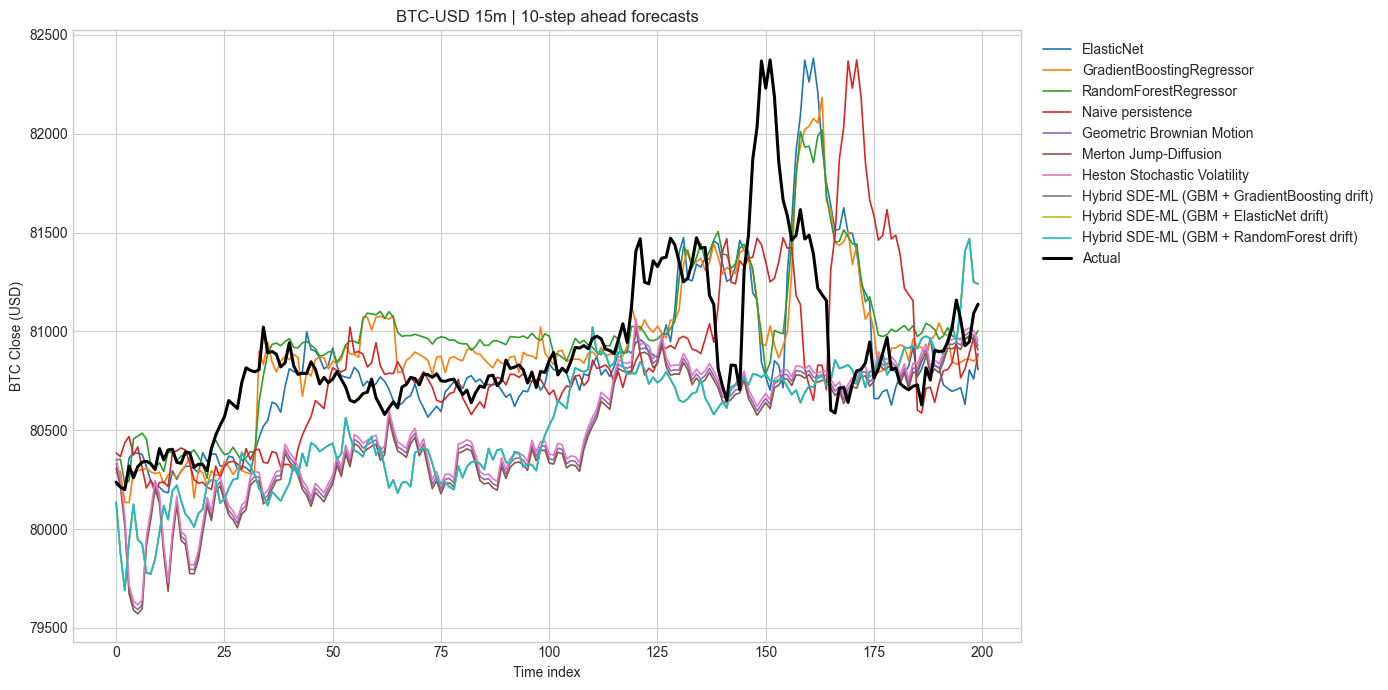

In [19]:
plt.figure(figsize=(14, 7))
for model_name, (y_true, y_pred) in predictions.items():
    plt.plot(y_pred[200:400], label=model_name, linewidth=1.2)

plt.plot(y_test[200:400], label='Actual', color='black', linewidth=2.2)
plt.title(f'BTC-USD {INTERVAL} | {HORIZON}-step ahead forecasts')
plt.xlabel('Time index')
plt.ylabel('BTC Close (USD)')
plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()

[82673.20950949 82491.6121065  82517.07516751 ... 76550.67184195
 76567.13605863 76827.64746695]
[82675.39959271 82490.40682575 82522.30536316 ... 76554.96635891
 76569.48202938 76826.44377177]
[82675.03417042 82490.43753214 82522.20289262 ... 76554.2846717
 76569.34353031 76826.78086266]


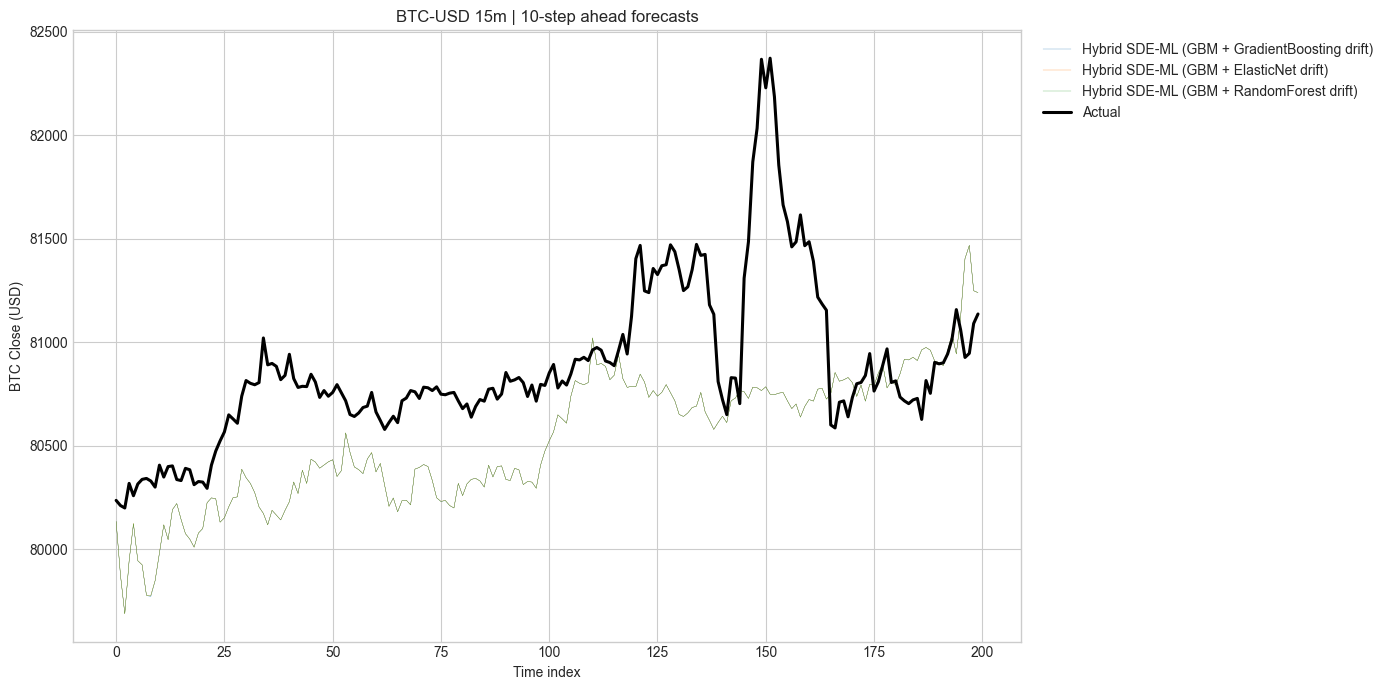

In [20]:
plt.figure(figsize=(14, 7))
for model_name, (y_true, y_pred) in predictions.items():
    if model_name.startswith('Hybrid'):
        print(y_pred)
        plt.plot(y_pred[200:400], label=model_name, linewidth=0.2)

plt.plot(y_test[200:400], label='Actual', color='black', linewidth=2.2)
plt.title(f'BTC-USD {INTERVAL} | {HORIZON}-step ahead forecasts')
plt.xlabel('Time index')
plt.ylabel('BTC Close (USD)')
plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()

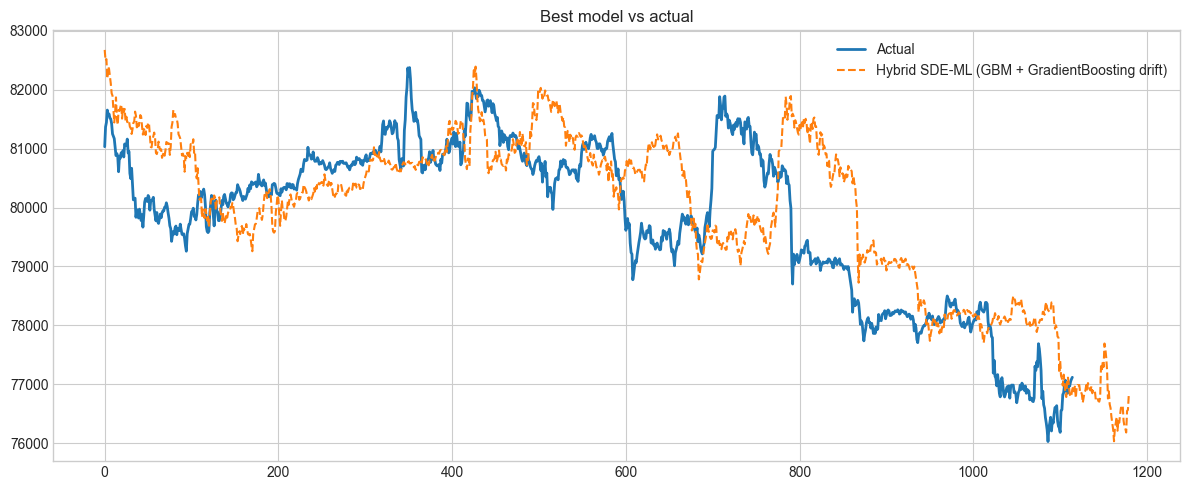

In [21]:
best_model_name = results_df.iloc[0]['model']
best_true, best_pred = predictions[best_model_name]

plt.figure(figsize=(12, 5))
plt.plot(y_test, label='Actual', linewidth=2)
plt.plot(best_pred, label=best_model_name, linestyle='--')
plt.title('Best model vs actual')
plt.legend()
plt.tight_layout()

In [22]:
economic_predictions = {name: pred for name, (_, pred) in predictions.items() if name in ['Naive persistence', 'ElasticNet', 'GradientBoostingRegressor', 'LSTM', 'Hybrid SDE-ML (GBM + GradientBoosting drift)']}
economic_y_true = predictions[next(iter(economic_predictions))][0] if economic_predictions else np.array([])
for name, (y_true_model, y_pred_model) in predictions.items():
    if name in economic_predictions:
        economic_y_true = y_true_model
        break
economic_df = compare_strategies(economic_y_true, economic_predictions) if len(economic_y_true) else pd.DataFrame()
economic_df

,Strategy,Total Return (%),Sharpe,Max Drawdown (%),Turnover,Number of Trades,PnL (USD)
0,Buy & Hold,-4.83,-5.23,-7.70,1.00,1,-482.67
1,ElasticNet,-16.93,-24.68,-17.59,160.00,160,-1692.89
2,GradientBoostingRegressor,-16.06,-24.09,-16.21,158.00,158,-1606.25
3,Naive persistence,-12.34,-17.76,-13.52,123.00,123,-1233.64
4,Hybrid SDE-ML (GBM + GradientBoosting drift),-7.22,-9.98,-9.04,53.00,53,-721.67
